# Where GPU data engineering starts to pay off

This output-complete notebook analyzes an end-to-end comparison of DuckDB CPU,
Polars CPU streaming, Polars GPU with CPU fallback disabled, and native cuDF.
It also preserves the failed native-cuDF larger-than-VRAM control.

The measured boundary begins before Parquet input and ends after a CPU-backed
Arrow result is materialized. Every accepted timing matched the canonical
reference result.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RESULTS = Path("results/published_results.csv")
FAILED = Path("results/failed_controls.csv")
results = pd.read_csv(RESULTS)
failed = pd.read_csv(FAILED)
results.groupby("study").size().rename("derived conditions").to_frame()


,derived conditions
study,
codec,24
crossover,168
out_of_core,4


## Experimental boundary

- Hardware: NVIDIA RTX PRO 4000 Blackwell SFF, 24 GB VRAM; eight CPU threads.
- Software: Python 3.12.13, DuckDB 1.5.5, Polars 1.42.1, cuDF 26.08.00,
  PyArrow 23.0.1, in a pinned CUDA 13.1 container.
- Data: deterministic synthetic Parquet, 262,144-row groups, warm-cache trials.
- Evidence: 196 engine/workload conditions and 588 measured timings, three per
  condition, plus warmups and strict result checks.
- Scope: local NVMe input and CPU-backed output. These are workstation boundary
  measurements, not universal framework rankings.

The public tables contain derived medians, ranges, process RSS, utilization,
and correctness status. Raw host telemetry and infrastructure identifiers stay
in the private experiment workspace.


In [2]:
assert results["correct"].all()
assert results["trials"].min() >= 3
assert len(results) == 196
assert int(results["trials"].sum()) == 588
results.groupby(["study", "workload"])["engine"].nunique().unstack(fill_value=0)


workload,feature_width_12,feature_width_2,feature_width_6,join_groupby,scan_groupby,sort_topk,string_features
study,,,,,,,
codec,4,0,0,0,4,0,4
crossover,4,4,4,4,4,4,4
out_of_core,4,0,0,0,0,0,0


## 1. Crossover: size changes the winner

All engines perform the same end-to-end work. Log scales keep 100,000 through
50 million rows readable together.


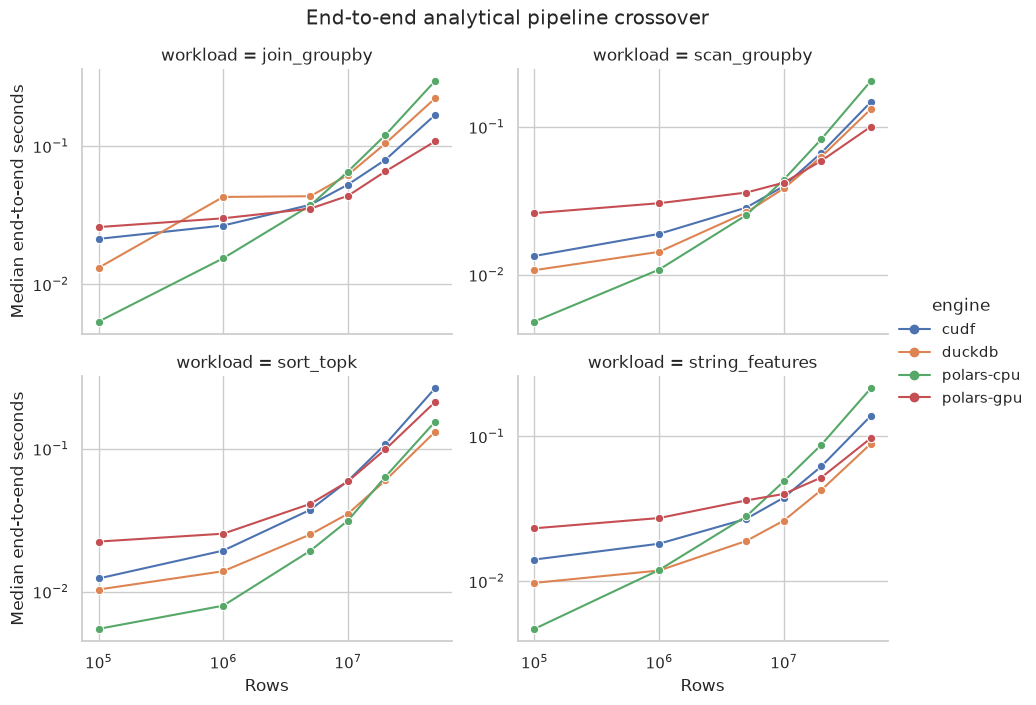

In [3]:
crossover = results[results["study"] == "crossover"].copy()
core_names = ["scan_groupby", "join_groupby", "string_features", "sort_topk"]
core = crossover[crossover["workload"].isin(core_names)]
grid = sns.relplot(
    data=core, x="rows", y="median_seconds", hue="engine",
    col="workload", col_wrap=2, kind="line", marker="o",
    facet_kws={"sharey": False}, height=3.4, aspect=1.35,
)
grid.set(xscale="log", yscale="log")
grid.set_axis_labels("Rows", "Median end-to-end seconds")
grid.figure.suptitle("End-to-end analytical pipeline crossover", y=1.03)
plt.show()


## 2. Width means columns actually processed

Adding unused columns is not a width benchmark because projection removes
them. These workloads calculate a feature score from 2, 6, or 12 metric
columns before aggregation.


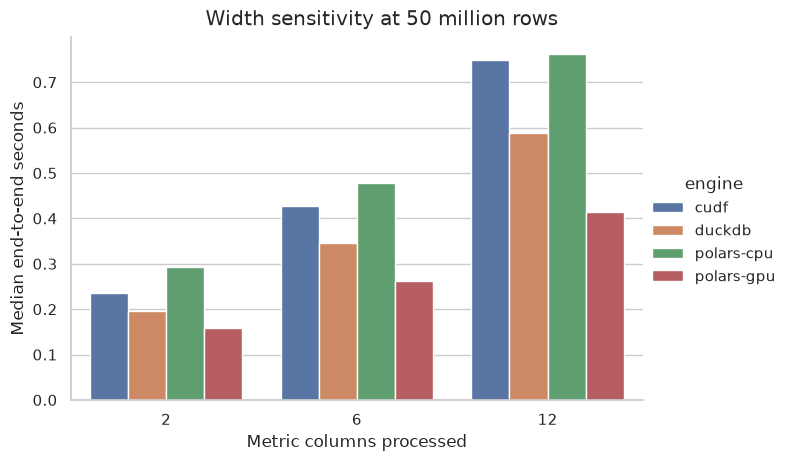

In [4]:
width = crossover[crossover["workload"].str.startswith("feature_width_")].copy()
width["metrics"] = width["workload"].str.rsplit("_", n=1).str[-1].astype(int)
largest = width[width["rows"] == 50_000_000]
chart = sns.catplot(
    data=largest, x="metrics", y="median_seconds", hue="engine",
    kind="bar", height=4.5, aspect=1.5,
)
chart.set_axis_labels("Metric columns processed", "Median end-to-end seconds")
chart.figure.suptitle("Width sensitivity at 50 million rows", y=1.02)
plt.show()


## 3. Measured crossover boundaries


In [5]:
winners = (
    crossover.sort_values("median_seconds")
    .groupby(["rows", "workload"], as_index=False)
    .first()[["rows", "workload", "engine", "median_seconds"]]
)
winners.pivot(index="workload", columns="rows", values="engine")


rows,100000,1000000,5000000,10000000,20000000,50000000
workload,,,,,,
feature_width_12,polars-cpu,polars-cpu,duckdb,polars-gpu,polars-gpu,polars-gpu
feature_width_2,polars-cpu,polars-cpu,polars-cpu,duckdb,polars-gpu,polars-gpu
feature_width_6,polars-cpu,polars-cpu,duckdb,duckdb,polars-gpu,polars-gpu
join_groupby,polars-cpu,polars-cpu,polars-gpu,polars-gpu,polars-gpu,polars-gpu
scan_groupby,polars-cpu,polars-cpu,polars-cpu,duckdb,polars-gpu,polars-gpu
sort_topk,polars-cpu,polars-cpu,polars-cpu,polars-cpu,duckdb,duckdb
string_features,polars-cpu,duckdb,duckdb,duckdb,duckdb,duckdb


In [6]:
gpu_engines = {"polars-gpu", "cudf"}
boundaries = []
for workload, group in winners.groupby("workload"):
    gpu_rows = group.loc[group["engine"].isin(gpu_engines), "rows"]
    boundaries.append({
        "workload": workload,
        "first_measured_GPU_win": (
            f"{int(gpu_rows.min()):,} rows" if not gpu_rows.empty else "No GPU win through 50,000,000"
        ),
    })
pd.DataFrame(boundaries).set_index("workload")


,first_measured_GPU_win
workload,
feature_width_12,"10,000,000 rows"
feature_width_2,"20,000,000 rows"
feature_width_6,"20,000,000 rows"
join_groupby,"5,000,000 rows"
scan_groupby,"20,000,000 rows"
sort_topk,"No GPU win through 50,000,000"
string_features,"No GPU win through 50,000,000"


## 4. Parquet codec is part of the workload

This controlled 20-million-row matrix changes only Snappy versus Zstandard.
Codec effects are shown per engine and query; there is no single codec winner
independent of the execution path.


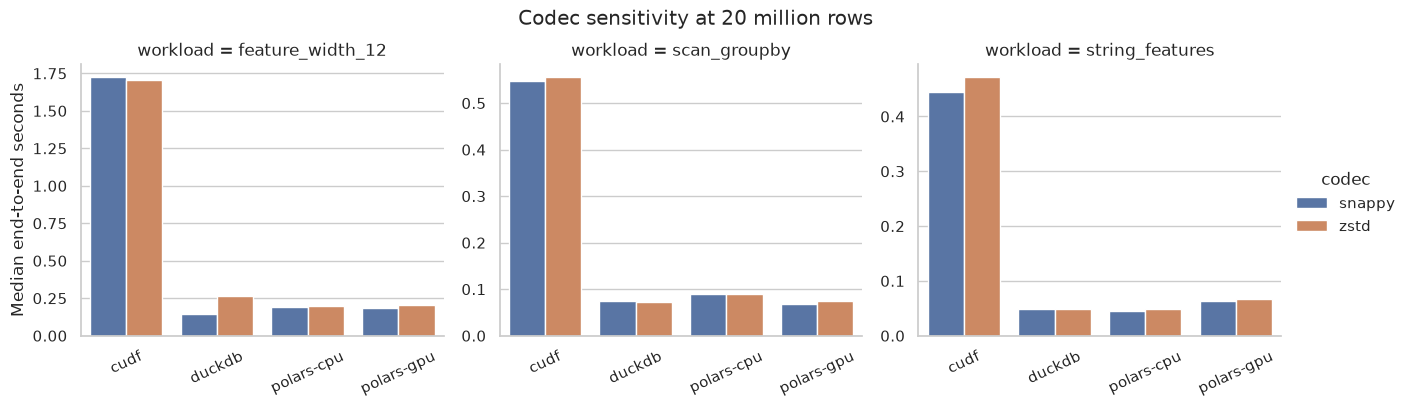

In [7]:
codec = results[results["study"] == "codec"].copy()
grid = sns.catplot(
    data=codec, x="engine", y="median_seconds", hue="codec",
    col="workload", kind="bar", sharey=False, height=3.8, aspect=1.15,
)
grid.set_axis_labels("", "Median end-to-end seconds")
grid.set_xticklabels(rotation=25)
grid.figure.suptitle("Codec sensitivity at 20 million rows", y=1.04)
plt.show()


## 5. Larger than VRAM: execution strategy matters

The 200-million-row wide dataset is 34.6 GB logical and 19.7 GB compressed,
or about 1.34 times the nominal 24 GiB device capacity. Polars GPU completed
with its streaming executor and CPU fallback disabled.

Native cuDF's one-shot read is retained below as a failed control. The separate
`cudf-streaming` condition is an explicit bounded algorithm: read one file at a
time, compute exact GPU partial sums/counts, then merge the tiny aggregates. It
is not evidence that arbitrary cuDF programs become out-of-core automatically.


In [8]:
ooc = results[results["study"] == "out_of_core"].copy()
ooc["median_seconds"] = ooc["median_seconds"].round(3)
ooc[["engine", "median_seconds", "relative_to_fastest", "process_rss_peak_bytes"]].sort_values("median_seconds")


,engine,median_seconds,relative_to_fastest,process_rss_peak_bytes
195,polars-gpu,1.538,1.000000,9225936896
194,polars-cpu,1.854,1.205411,10405511168
193,duckdb,2.278,1.481343,9046335488
192,cudf-streaming,13.931,9.058246,9230073856


In [9]:
failed[["engine", "outcome", "reason"]]


,engine,outcome,reason
0,cudf,failed,Single-shot read attempted a 23.3 GB device al...


## 6. Memory and utilization

Peak RSS is the benchmark process resident set; GPU utilization is sampled
through NVML. Whole-device memory is intentionally omitted from public engine
comparisons because unrelated resident services and allocator reuse prevent
honest per-process attribution.


In [10]:
memory = results.assign(rss_peak_gib=results["process_rss_peak_bytes"] / 1024**3)
memory.groupby(["study", "engine"])[["rss_peak_gib", "gpu_utilization_mean_percent"]].max().round(2)


rss_peak_gib  gpu_utilization_mean_percent
study       engine                                                    
codec       cudf                    4.16                         38.69
            duckdb                  3.33                         38.67
            polars-cpu              4.46                         33.00
            polars-gpu              3.23                         44.00
crossover   cudf                    3.97                         59.55
            duckdb                  4.00                         55.82
            polars-cpu              4.89                         64.33
            polars-gpu              3.96                         76.67
out_of_core cudf-streaming          8.60                         59.08
            duckdb                  8.43                          3.73
            polars-cpu              9.69                          9.43
            polars-gpu              8.59                         78.24

## What this evidence supports

1. **Projection is the first optimization.** Width mattered only when queries
   actually consumed the extra columns.
2. **GPU payoff is a curve, not a label.** In this matrix the first GPU win was
   5 million rows for the join, 10 million for the 12-column feature workload,
   and 20 million for the scan and 2/6-column feature workloads.
3. **Strings and filtered top-k stayed CPU territory through 50 million rows.**
   DuckDB won both at the largest measured size.
4. **A GPU-capable plan can exceed VRAM when it streams.** Polars GPU was fastest
   on the 34.6 GB logical dataset, but native cuDF's one-shot read failed and
   the manual cuDF partition loop was about nine times slower.
5. **Codec and execution engine interact.** Snappy versus Zstandard changed
   timings and occasionally the CPU winner; choose with the actual query and
   storage constraints, not a universal codec rule.
6. **End-to-end boundaries are conservative by design.** If the next stage
   remains GPU-resident, avoiding the final CPU materialization may move the
   break-even point earlier; remote storage, cold cache, and tiny-file overhead
   may move it elsewhere.

The practical rule is: reduce columns early, keep a CPU reference, benchmark
the complete query at representative sizes, and use GPU execution once enough
parallel work survives I/O and setup overhead. For data beyond VRAM, require a
verified streaming or partitioning plan—"spilling enabled" is not itself a
guarantee.
